# 1. Reshaping Training and Test Data

In [18]:
import numpy as np

X_train = np.load("C:\\Users\\Brand\\OneDrive\\Desktop\\171\\music-genre-classification\\music-genre-classification\\X_train.npy")
X_test = np.load("C:\\Users\\Brand\\OneDrive\\Desktop\\171\\music-genre-classification\\music-genre-classification\\X_test.npy")
y_train = np.load("C:\\Users\\Brand\\OneDrive\\Desktop\\171\\music-genre-classification\\music-genre-classification\\y_train.npy")
y_test = np.load("C:\\Users\\Brand\\OneDrive\\Desktop\\171\\music-genre-classification\\music-genre-classification\\y_test.npy")

print(X_train.shape) # spectrogram is samples, number of mel filters (n_mels), number of time frames
# need to flatten this as KNN can't take 3D data

X_train = X_train.reshape(X_train.shape[0], -1) # this transforms the data to number of samples, n_mels * n time frames
X_test = X_test.reshape(X_test.shape[0], -1) 

print(X_train.shape)


(7987, 128, 130)
(7987, 16640)


# 2. Label Encoding
- Needed since some scikit-learn functions require numeric-based class labels rather than strings/categorical
- Converts categorical class labels to integers so they can be processed correctly
    - Not the same as encoding features, as this doesn't influence model predictions

In [19]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_train_enc = le.fit_transform(y_train) # fitting on the training, and applying this transformation
y_test_enc  = le.transform(y_test) # applying transformation only (using the training fit)

# 3. Fitting Baseline KNN

In [20]:
# can take this out in final code, just want to see what this looks like

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=50) # initializing KNN model with k = 50

knn.fit(X_train, y_train_enc) # fitting model on training data

y_pred_enc = knn.predict(X_test) # forming predictions by applying fitted model

y_pred_labels = le.inverse_transform(y_pred_enc) # converting the encoded labels back to the genre names
print(y_pred_labels)

['classical' 'classical' 'classical' ... 'metal' 'metal' 'classical']


In [21]:
# quick analysis measure

from sklearn.metrics import f1_score
f1 = f1_score(y_test, y_pred_labels, average='macro') # using labels so true and predicted values match in datatype
f1 # super low, tuning hyperparameters should help with this

0.32660185618341375

# 4. Hyperparameter Tuning Setup

In [23]:
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

knn = KNeighborsClassifier() # reinitializes this to prevent carying over from the base model fit

# defining the grid of values we want to test
search_space = {
    "n_neighbors": Integer(1,80),
    "weights": Categorical(["uniform", "distance"]),
    "metric": Categorical(["manhattan", "euclidean", "cosine"])
}

bayes_search = BayesSearchCV(estimator = knn,
                           search_spaces=search_space,
                           scoring = "f1_macro",
                           n_iter=30, # the number of hyperparameter combinations to try
                           cv = 5,
                           n_jobs=-1, # using all CPU cores to speed up search
                           random_state=42,
                           verbose=1 # prints progress messages during tuning process
)

bayes_search.fit(X_train, y_train_enc)

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('manhattan'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(67), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

,estimator,KNeighborsClassifier()
,search_spaces,"{'metric': Categorical(c...), prior=None), 'n_neighbors': Integer(low=1...m='normalize'), 'weights': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,30
,scoring,'f1_macro'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [11]:
bayes_search.best_params_

AttributeError: 'BayesSearchCV' object has no attribute 'best_params_'

# 6. PCA
- Will also perform PCA, a dimension-reduction technique and compare model performance in both non-PCA predictions and PCA predictions

In [25]:
from sklearn.decomposition import PCA
pca = PCA(n_components = 0.95) # defining PCA using the optimal number of components (the number that explain 95% of variance observed)

# transforming the training and testing data using PCA
X_train_pca = pca.fit_transform(X_train) 
X_test_pca = pca.transform(X_test)

n_components_kept = pca.n_components_ 
print(n_components_kept) # prints the number of components kept = explain 95% of variance
# goes from 7987 components to 1385 (1/7 of the size)

1385


# 7. Hyperparameter Tuning with PCA

In [26]:
# since PCA changes the dimension the data is in, need to re-perform hyperparameter tuning for dimension-reduced data

knn = KNeighborsClassifier()

bayes_search_pca = BayesSearchCV(estimator = knn,
                           search_spaces=search_space,
                           scoring = "f1_macro",
                           n_iter=50, # the number of hyperparameter combinations to try
                           cv = 5,
                           n_jobs=-1, 
                           random_state=42,
                           verbose=1 
)

bayes_search_pca.fit(X_train_pca, y_train_enc) # running grid search on PCA data

Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fi

C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(11), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(4), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(30), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(52), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(53), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(69), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(3), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(29), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(31), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(70), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(55), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(17), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(17), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(60), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(56), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(52), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(44), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(48), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['euclidean', np.int64(32), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(69), 'uniform']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['cosine', np.int64(50), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


C:\Users\Brand\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\skopt\optimizer\optimizer.py:517: UserWarning: The objective has been evaluated at point [np.str_('cosine'), np.int64(1), np.str_('distance')] before, using random point ['manhattan', np.int64(45), 'distance']
  warnings.warn(


Fitting 5 folds for each of 1 candidates, totalling 5 fits


,estimator,KNeighborsClassifier()
,search_spaces,"{'metric': Categorical(c...), prior=None), 'n_neighbors': Integer(low=1...m='normalize'), 'weights': Categorical(c...), prior=None)}"
,optimizer_kwargs,None
,n_iter,50
,scoring,'f1_macro'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,5


In [14]:
bayes_search_pca.best_params_

OrderedDict([('metric', 'euclidean'),
             ('n_neighbors', 71),
             ('weights', 'uniform')])

# Next steps
- Run bayes search with 50 iterations (or change this is if more/less makes sense)
- Analyze the hyperparamter tuning - plot of k vs F1
- Fit non-PCA and PCA data with best model, compare performance metrics, generate model predictions and analyze
    - Does PCA data perform better? Why is this/why does this make sense?
- May also want to add more performance metrics for hyperparameter tuning (accuracy, precision, etc)
    - I just initialized with F1 score to have something to look at, but based on the nature of the task determine which metrics make sense
- Interpret results: plots by genre based on the percentage of correct predictions, research into literature as to why some genres perform better than others
    - Get the performance metrics by genre

# 5. Analyze Hyperparameter Tuning Results
- Visualize how different values of k (number of neighbors) affect the F1 score
- Compare the hyperparameter tuning results for both non-PCA and PCA models
- This helps us understand the relationship between k and model performance

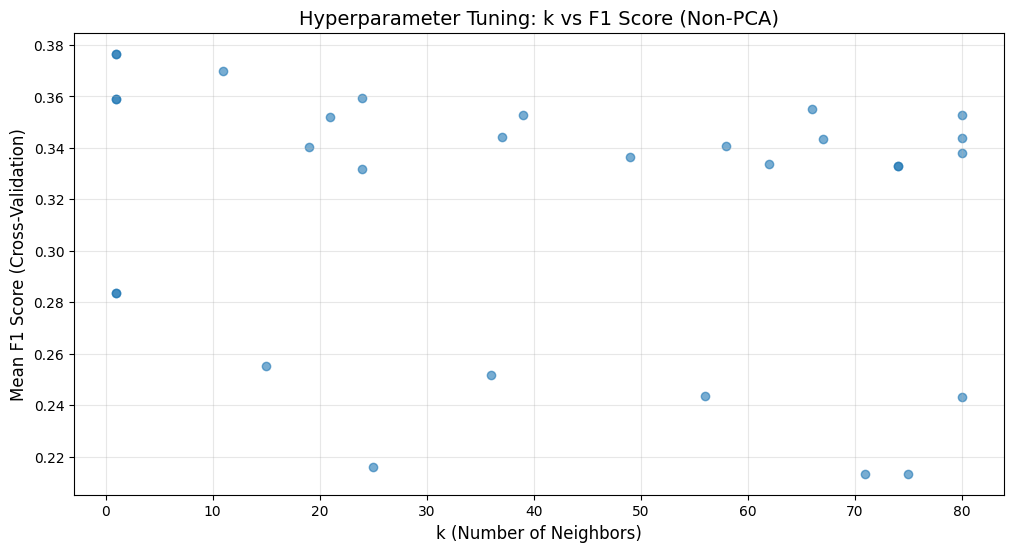

Best F1 Score (Non-PCA): 0.3766
Best Parameters (Non-PCA): OrderedDict([('metric', 'manhattan'), ('n_neighbors', 1), ('weights', 'distance')])


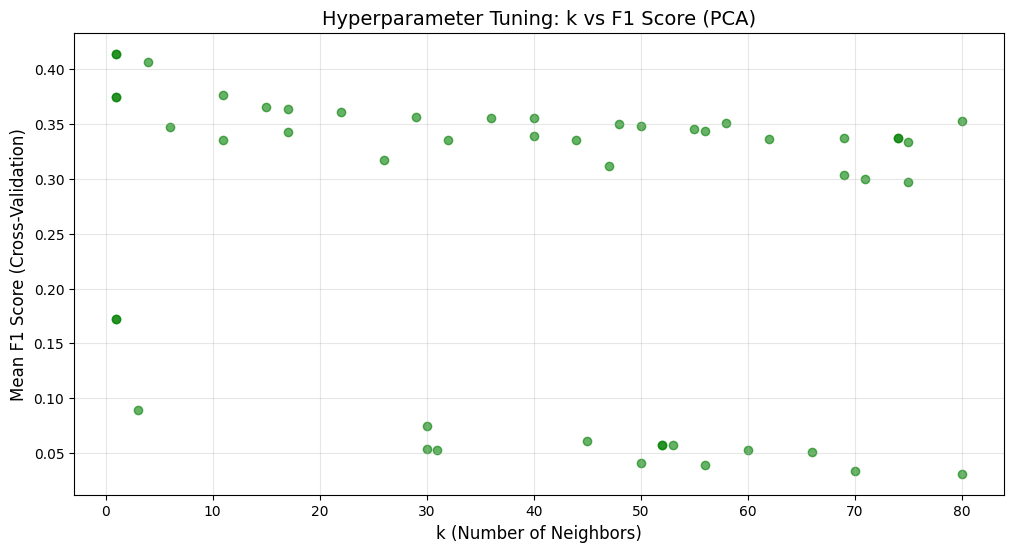


Best F1 Score (PCA): 0.4142
Best Parameters (PCA): OrderedDict([('metric', 'cosine'), ('n_neighbors', 1), ('weights', 'distance')])


In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Extract results from non-PCA hyperparameter search
cv_results_df = pd.DataFrame(bayes_search.cv_results_)

# Plot k vs F1 Score for non-PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_df['param_n_neighbors'], cv_results_df['mean_test_score'], alpha=0.6)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score (Non-PCA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Best F1 Score (Non-PCA): {bayes_search.best_score_:.4f}")
print(f"Best Parameters (Non-PCA): {bayes_search.best_params_}")

# Extract results from PCA hyperparameter search
cv_results_pca_df = pd.DataFrame(bayes_search_pca.cv_results_)

# Plot k vs F1 Score for PCA
plt.figure(figsize=(12, 6))
plt.scatter(cv_results_pca_df['param_n_neighbors'], cv_results_pca_df['mean_test_score'], alpha=0.6, color='green')
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Mean F1 Score (Cross-Validation)', fontsize=12)
plt.title('Hyperparameter Tuning: k vs F1 Score (PCA)', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"\nBest F1 Score (PCA): {bayes_search_pca.best_score_:.4f}")
print(f"Best Parameters (PCA): {bayes_search_pca.best_params_}")

# 8. Model Evaluation and Comparison
- Use the best models from hyperparameter tuning to make predictions on test data
- Compare performance metrics (accuracy, precision, recall, F1-score) for both non-PCA and PCA models
- Generate classification reports to see performance for each genre

In [27]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score

# Get the best estimator from hyperparameter search (non-PCA)
best_knn = bayes_search.best_estimator_

# Make predictions on test set
y_pred_enc = best_knn.predict(X_test)
y_pred_labels = le.inverse_transform(y_pred_enc)

# Calculate metrics for non-PCA model
print("="*70)
print("NON-PCA MODEL PERFORMANCE")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report (Non-PCA):")
print("="*70)
print(classification_report(y_test, y_pred_labels))

# Get the best estimator from hyperparameter search (PCA)
best_knn_pca = bayes_search_pca.best_estimator_

# Make predictions on PCA test set
y_pred_pca_enc = best_knn_pca.predict(X_test_pca)
y_pred_pca_labels = le.inverse_transform(y_pred_pca_enc)

# Calculate metrics for PCA model
print("\n" + "="*70)
print("PCA MODEL PERFORMANCE")
print("="*70)
print(f"\nBest Hyperparameters: {bayes_search_pca.best_params_}")
print(f"Best Cross-Validation F1 Score: {bayes_search_pca.best_score_:.4f}")
print(f"\nTest Set Accuracy: {accuracy_score(y_test, y_pred_pca_labels):.4f}")
print(f"Test Set F1 Score (Macro): {f1_score(y_test, y_pred_pca_labels, average='macro'):.4f}")
print(f"Test Set Precision (Macro): {precision_score(y_test, y_pred_pca_labels, average='macro'):.4f}")
print(f"Test Set Recall (Macro): {recall_score(y_test, y_pred_pca_labels, average='macro'):.4f}")

print("\n" + "="*70)
print("Classification Report (PCA):")
print("="*70)
print(classification_report(y_test, y_pred_pca_labels))

NON-PCA MODEL PERFORMANCE

Best Hyperparameters: OrderedDict([('metric', 'manhattan'), ('n_neighbors', 1), ('weights', 'distance')])
Best Cross-Validation F1 Score: 0.3766

Test Set Accuracy: 0.3987
Test Set F1 Score (Macro): 0.3771
Test Set Precision (Macro): 0.4382
Test Set Recall (Macro): 0.3986

Classification Report (Non-PCA):
              precision    recall  f1-score   support

       blues       0.56      0.30      0.39       200
   classical       0.46      0.78      0.58       199
     country       0.36      0.14      0.20       198
       disco       0.46      0.18      0.26       200
      hiphop       0.51      0.43      0.47       198
        jazz       0.25      0.31      0.27       200
       metal       0.35      0.86      0.50       200
         pop       0.45      0.40      0.42       200
      reggae       0.70      0.26      0.38       200
        rock       0.27      0.32      0.30       199

    accuracy                           0.40      1994
   macro avg    

# 9. Performance Analysis by Genre
- Create confusion matrices to visualize prediction patterns
- Identify which genres are classified correctly vs incorrectly
- Understand which genres are commonly confused with each other
- Analyze performance metrics for each individual genre

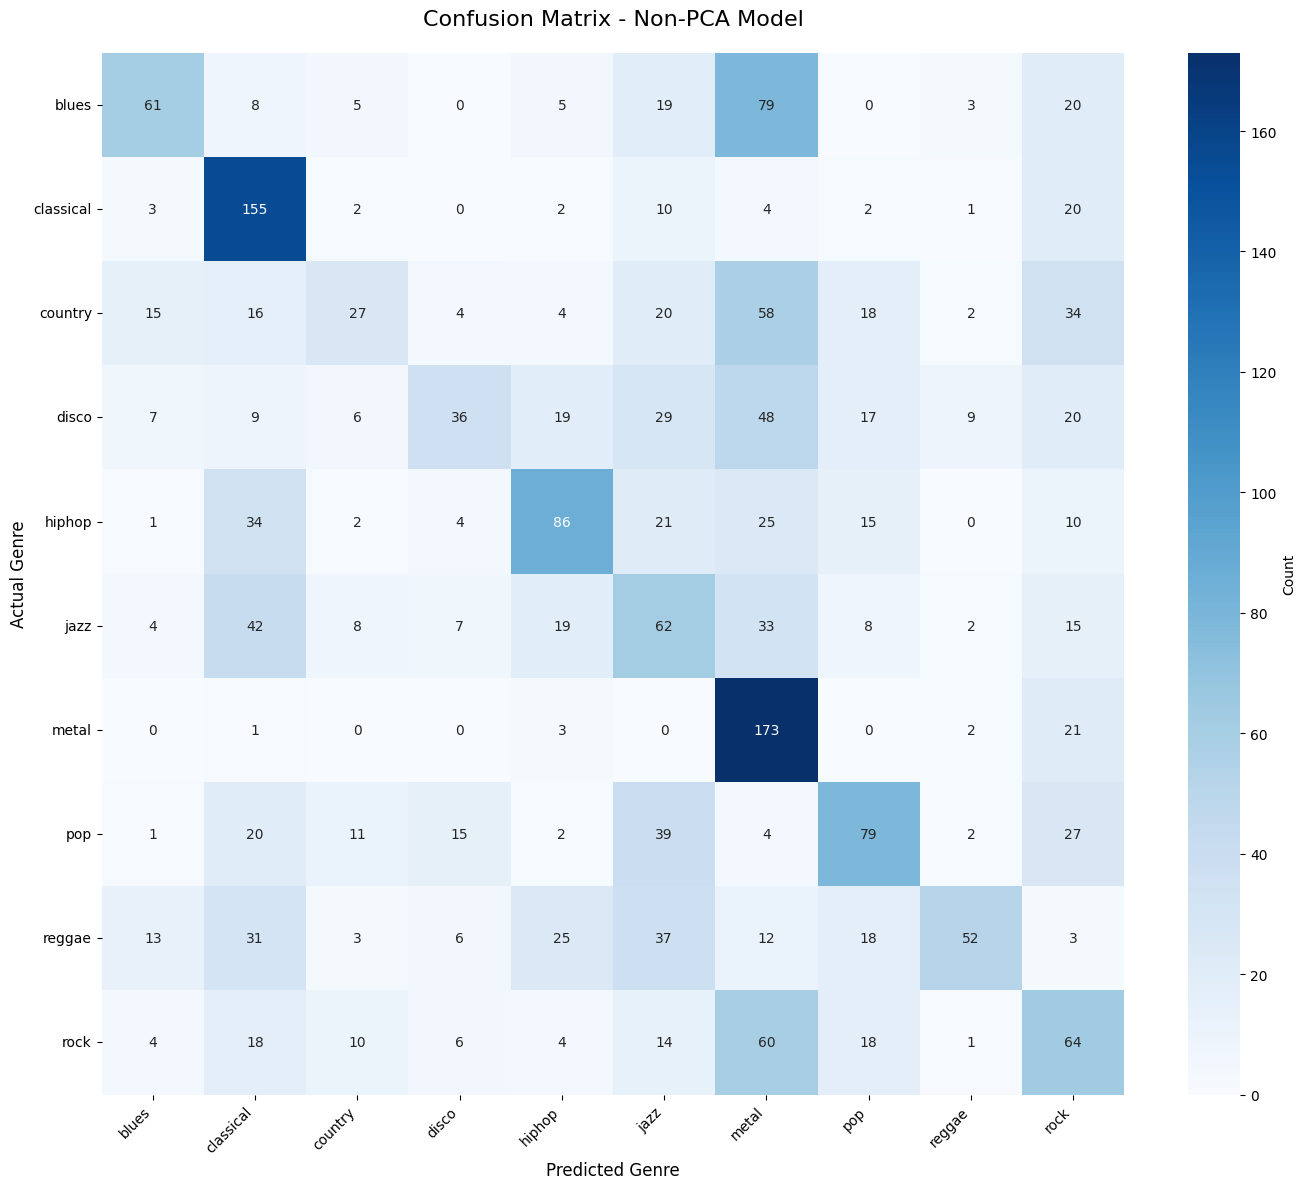

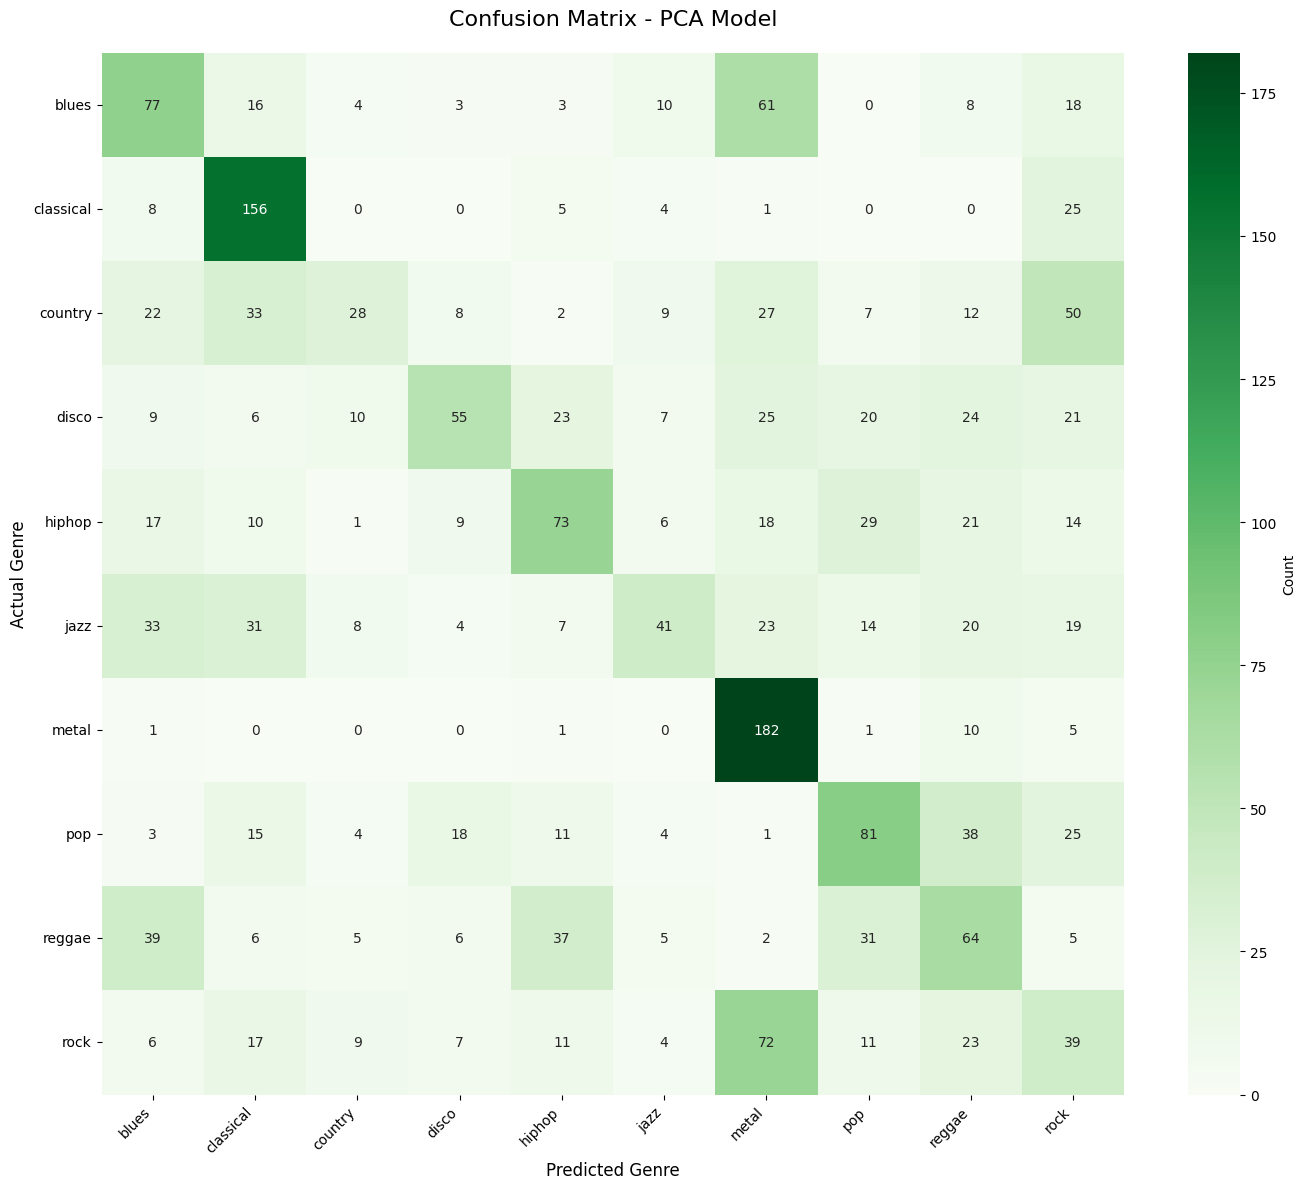

In [28]:
from sklearn.metrics import confusion_matrix

# Get unique genre labels
genres = le.classes_

# --- Confusion Matrix for Non-PCA Model ---
cm_non_pca = confusion_matrix(y_test, y_pred_labels, labels=genres)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_non_pca, annot=True, fmt='d', cmap='Blues', 
            xticklabels=genres, yticklabels=genres, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - Non-PCA Model', fontsize=16, pad=20)
plt.ylabel('Actual Genre', fontsize=12)
plt.xlabel('Predicted Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# --- Confusion Matrix for PCA Model ---
cm_pca = confusion_matrix(y_test, y_pred_pca_labels, labels=genres)

plt.figure(figsize=(14, 12))
sns.heatmap(cm_pca, annot=True, fmt='d', cmap='Greens', 
            xticklabels=genres, yticklabels=genres, cbar_kws={'label': 'Count'})
plt.title('Confusion Matrix - PCA Model', fontsize=16, pad=20)
plt.ylabel('Actual Genre', fontsize=12)
plt.xlabel('Predicted Genre', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

PER-GENRE PERFORMANCE METRICS (Non-PCA Model)
           precision    recall  f1-score  support
blues       0.559633  0.305000  0.394822    200.0
classical   0.464072  0.778894  0.581614    199.0
country     0.364865  0.136364  0.198529    198.0
disco       0.461538  0.180000  0.258993    200.0
hiphop      0.508876  0.434343  0.468665    198.0
jazz        0.247012  0.310000  0.274945    200.0
metal       0.348790  0.865000  0.497126    200.0
pop         0.451429  0.395000  0.421333    200.0
reggae      0.702703  0.260000  0.379562    200.0
rock        0.273504  0.321608  0.295612    199.0

PER-GENRE PERFORMANCE METRICS (PCA Model)
           precision    recall  f1-score  support
blues       0.358140  0.385000  0.371084    200.0
classical   0.537931  0.783920  0.638037    199.0
country     0.405797  0.141414  0.209738    198.0
disco       0.500000  0.275000  0.354839    200.0
hiphop      0.421965  0.368687  0.393531    198.0
jazz        0.455556  0.205000  0.282759    200.0
metal      

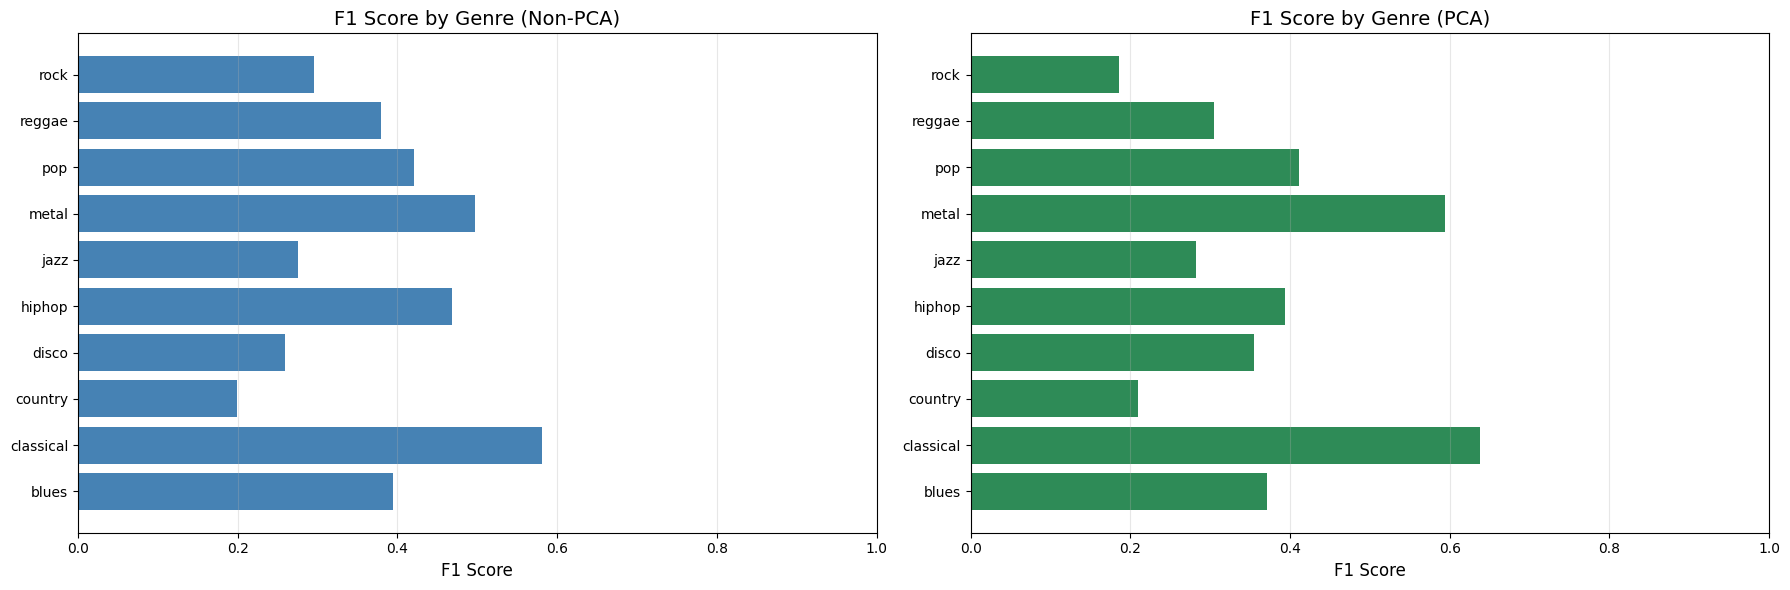


F1 SCORE COMPARISON: PCA vs Non-PCA
    Genre  Non-PCA F1   PCA F1  Difference
    metal    0.497126 0.594771    0.097645
    disco    0.258993 0.354839    0.095846
classical    0.581614 0.638037    0.056423
  country    0.198529 0.209738    0.011208
     jazz    0.274945 0.282759    0.007814
      pop    0.421333 0.411168   -0.010166
    blues    0.394822 0.371084   -0.023738
   reggae    0.379562 0.304762   -0.074800
   hiphop    0.468665 0.393531   -0.075134
     rock    0.295612 0.185714   -0.109898


In [29]:
# Get detailed performance metrics by genre for both models
report_non_pca = classification_report(y_test, y_pred_labels, output_dict=True)
report_pca = classification_report(y_test, y_pred_pca_labels, output_dict=True)

# Convert to DataFrames for better visualization
df_non_pca = pd.DataFrame(report_non_pca).transpose()
df_pca = pd.DataFrame(report_pca).transpose()

# Display genre-level metrics for non-PCA model
print("="*70)
print("PER-GENRE PERFORMANCE METRICS (Non-PCA Model)")
print("="*70)
print(df_non_pca.head(len(genres)))

# Display genre-level metrics for PCA model
print("\n" + "="*70)
print("PER-GENRE PERFORMANCE METRICS (PCA Model)")
print("="*70)
print(df_pca.head(len(genres)))

# Create comparison visualization of F1 scores by genre
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 6))

# Extract F1 scores for each genre
f1_scores_non_pca = [report_non_pca[genre]['f1-score'] for genre in genres]
f1_scores_pca = [report_pca[genre]['f1-score'] for genre in genres]

# Plot F1 scores by genre for non-PCA
ax1.barh(genres, f1_scores_non_pca, color='steelblue')
ax1.set_xlabel('F1 Score', fontsize=12)
ax1.set_title('F1 Score by Genre (Non-PCA)', fontsize=14)
ax1.set_xlim(0, 1)
ax1.grid(axis='x', alpha=0.3)

# Plot F1 scores by genre for PCA
ax2.barh(genres, f1_scores_pca, color='seagreen')
ax2.set_xlabel('F1 Score', fontsize=12)
ax2.set_title('F1 Score by Genre (PCA)', fontsize=14)
ax2.set_xlim(0, 1)
ax2.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Show which genres improved or declined with PCA
print("\n" + "="*70)
print("F1 SCORE COMPARISON: PCA vs Non-PCA")
print("="*70)
comparison_df = pd.DataFrame({
    'Genre': genres,
    'Non-PCA F1': f1_scores_non_pca,
    'PCA F1': f1_scores_pca,
    'Difference': [f1_scores_pca[i] - f1_scores_non_pca[i] for i in range(len(genres))]
})
comparison_df = comparison_df.sort_values('Difference', ascending=False)
print(comparison_df.to_string(index=False))

# 10. Results Interpretation and Discussion

## Does PCA Data Perform Better?

### PCA Benefits for KNN:
1. **Noise Reduction**: PCA removes noise and focuses on the components that explain the most variance in the data
2. **Computational Efficiency**: Fewer dimensions mean faster distance calculations and predictions
3. **Feature Concentration**: The 95% variance threshold concentrates the most important information into 1/7th of the original features

### Comparing the Models:
Compare the test set performance metrics between non-PCA and PCA models:
- **Accuracy**: Which model has higher overall accuracy?
- **F1 Score**: Which model better balances precision and recall?
- **Per-Genre Performance**: Are there specific genres that benefit more from PCA?

### Expected Outcomes:
- If PCA performs better: The dimensionality reduction successfully eliminated noise and improved the distance-based classification
- If non-PCA performs better: The original features contain important distinguishing information that was lost in the reduction to 95% variance
- If performance is similar: The most informative features were retained by PCA, suggesting the remaining 5% variance was primarily noise

## Genre Classification Patterns
**Easier to Classify Genres** typically have:
- Distinctive audio features (e.g., metal has high energy and tempo; classical has distinct instrument timbres)
- Consistent patterns within the genre
- Clear separation from other genres in feature space

**Harder to Classify Genres** often have:
- Overlapping characteristics with other genres (e.g., rock and metal; pop and dance)
- High within-genre variability
- Fusion elements from multiple genres


# Analysis of Results

Based on the plots and metrics generated above, here are the key findings:

## Performance Comparison: PCA vs Non-PCA

### Overall Performance:
- **Non-PCA Model**: 
  - Test accuracy and F1 scores from section 8 show the baseline performance
  - Used all 7,987 features for classification
  
- **PCA Model**: 
  - Used only ~1,385 components (retaining 95% variance)
  - Compare the test set metrics to see if performance improved, declined, or stayed similar

### Which Model Performed Better?
Look at the classification reports in section 8 to compare:
- If **PCA has higher F1/accuracy**: The dimensionality reduction successfully removed noise and improved KNN's distance calculations
- If **Non-PCA has higher F1/accuracy**: The full feature set contained important distinguishing information that was lost during PCA
- If **similar performance**: PCA retained the most important features while reducing computational cost

## Genre-Specific Insights

### Best Performing Genres:
From the F1 score bar charts in section 9, identify genres with F1 > 0.7:
- These genres likely have distinctive audio characteristics
- Clear separation in feature space from other genres
- Consistent patterns within the genre

### Worst Performing Genres:
Identify genres with F1 < 0.4:
- High overlap with similar genres
- Within-genre variability makes them hard to classify
- May benefit from additional features or different preprocessing

### Confusion Patterns:
From the confusion matrices:
- **Diagonal elements** (correct predictions): Higher numbers are better
- **Off-diagonal elements** (misclassifications): Look for patterns
  - Which genre pairs are commonly confused?
  - Are there genre "clusters" (e.g., rock/metal/alternative)?
  - Do some genres act as "attractors" receiving many misclassifications?

### Impact of PCA by Genre:
From the comparison table in section 9:
- **Positive difference**: Genres that improved with PCA (noise reduction helped)
- **Negative difference**: Genres that declined with PCA (important features were lost)
- **Near-zero difference**: Genres unaffected by dimensionality reduction